# Técnicas avanzadas de Diseño de software

----

## Sub interpretes

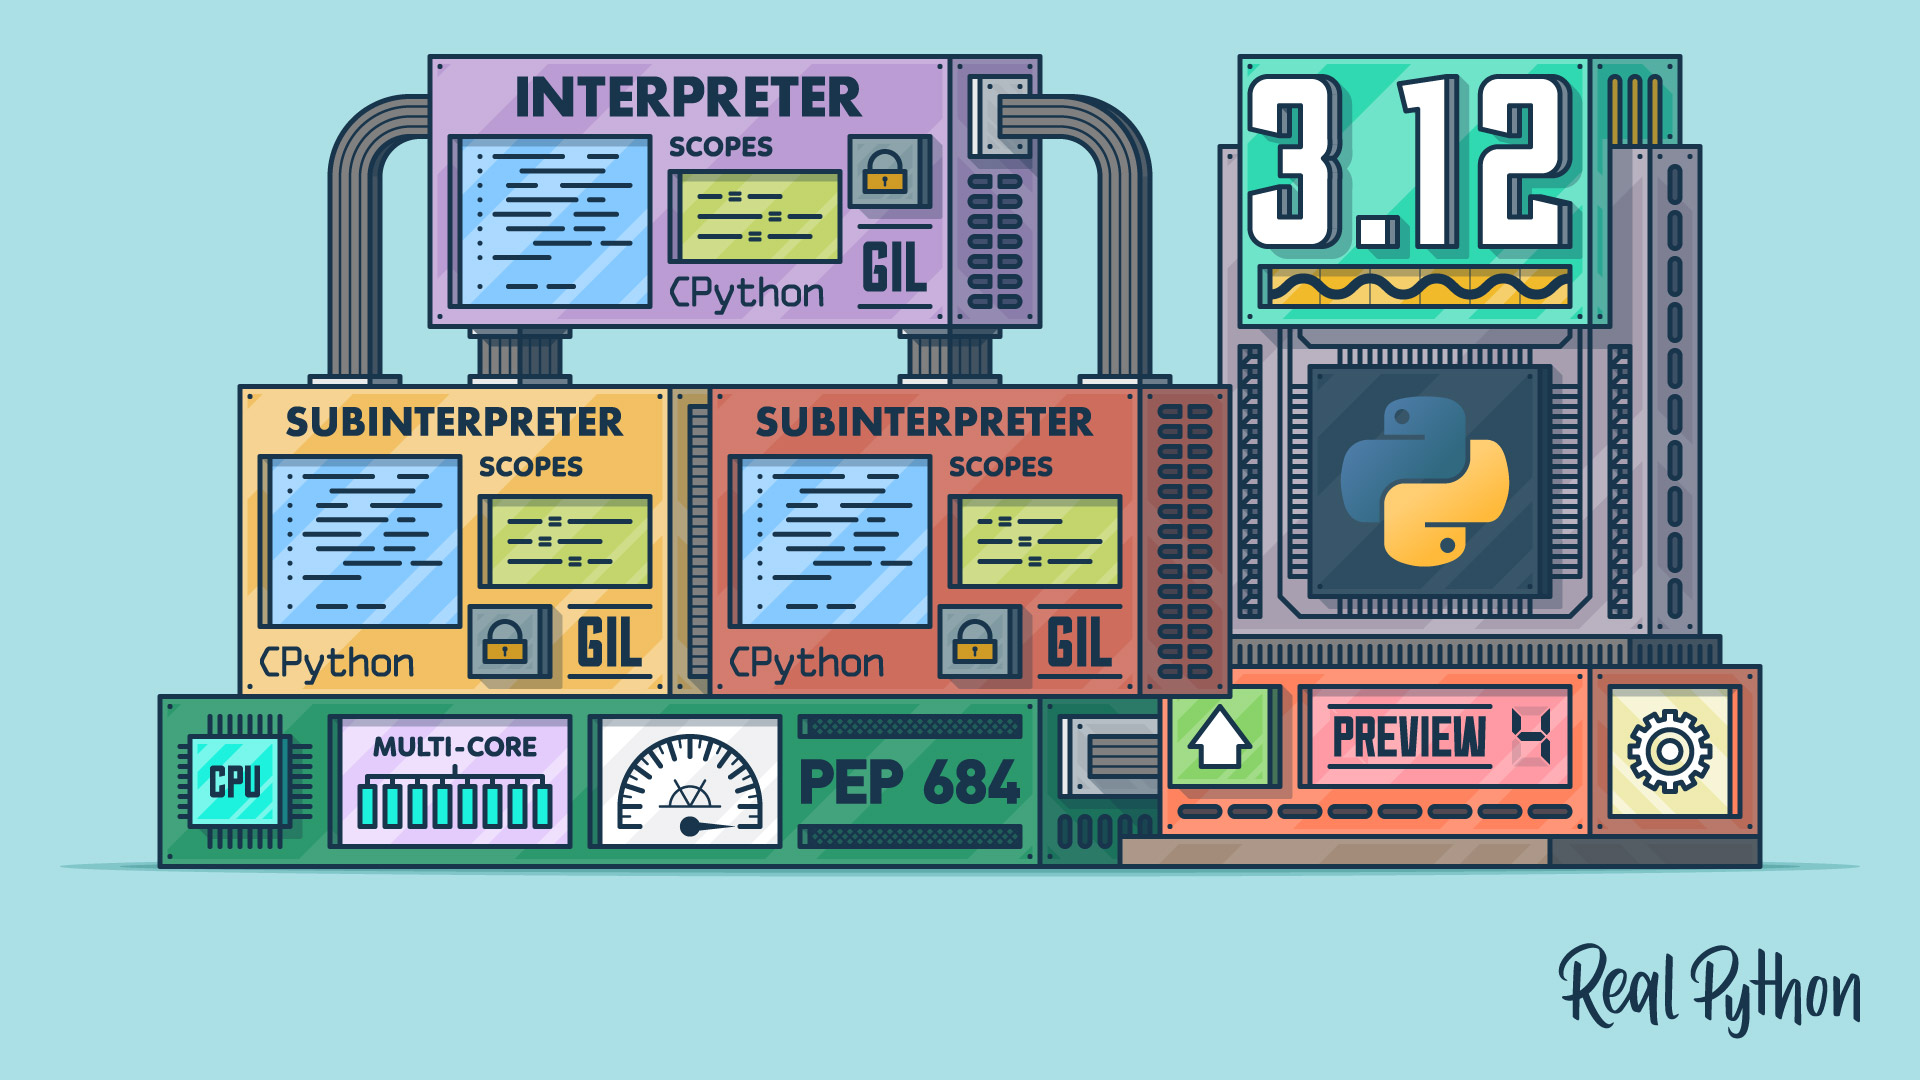

## El Desafío del Paralelismo en Python

### Problema Central
- Python es **inherentemente secuencial** debido al GIL
- Las máquinas modernas tienen **múltiples cores**
- Necesidad de **paralelismo real** para tareas CPU-intensivas
- Opciones actuales tienen **limitaciones significativas**

### Estado Actual

- Threading: I/O bound solamente
- Multiprocessing: Alto overhead, comunicación compleja
- AsyncIO: Concurrencia, no paralelismo


## El GIL es una ayuda, no un problema

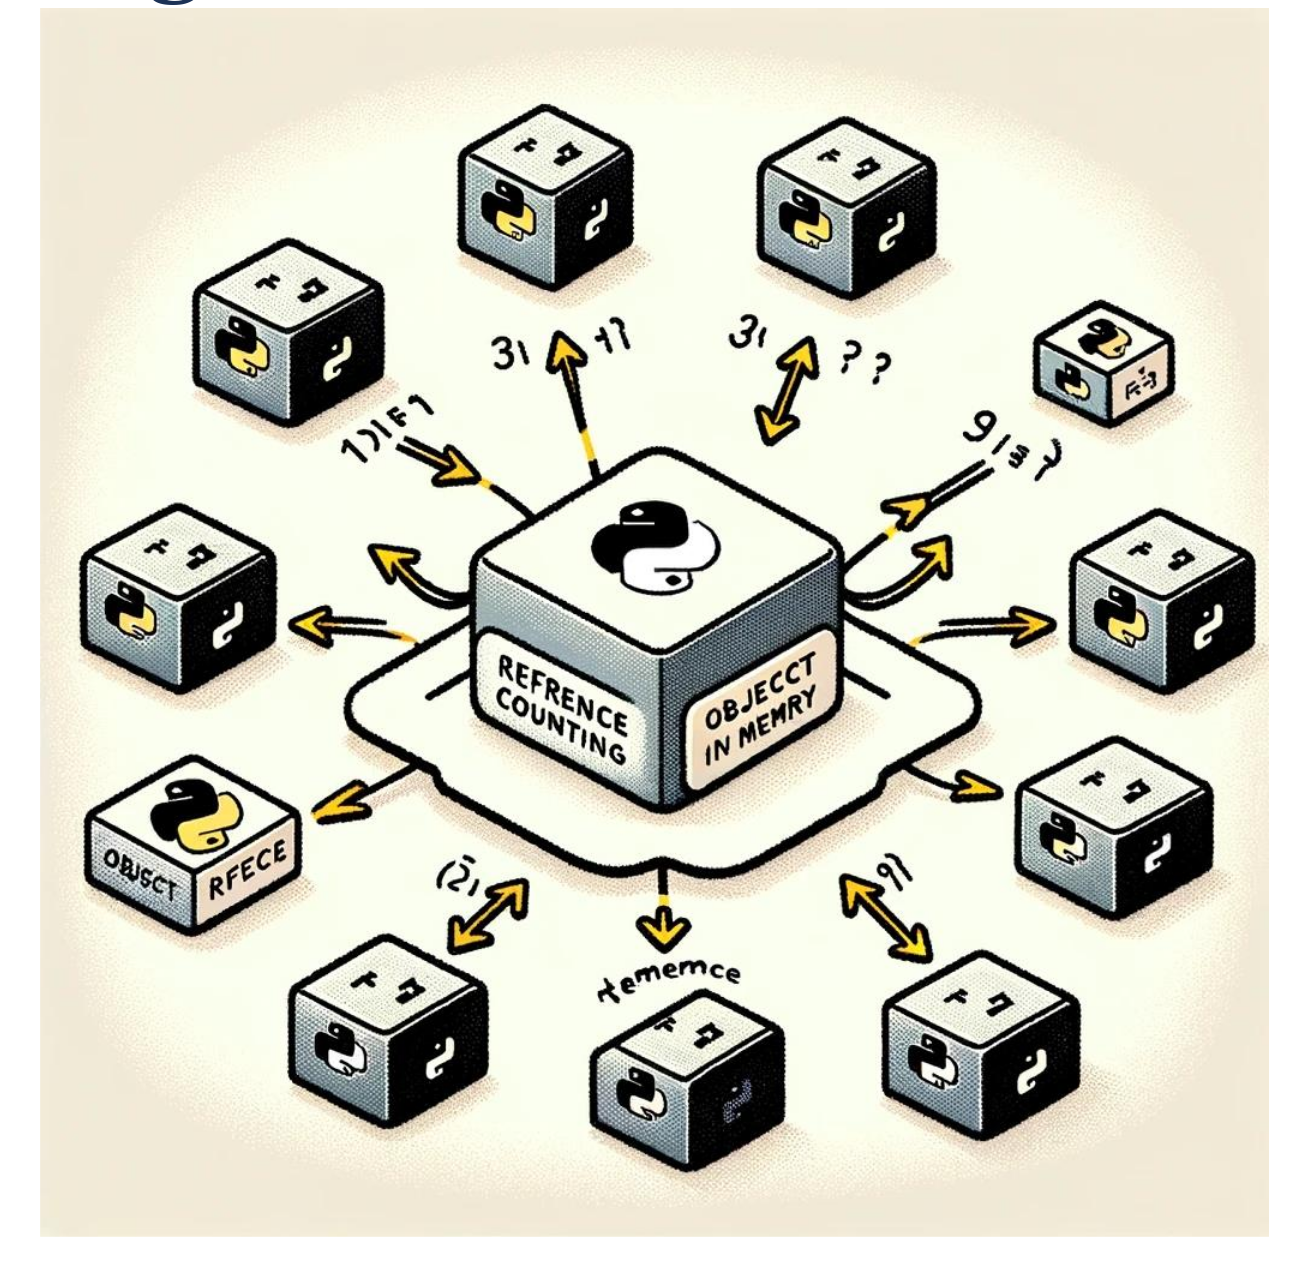

## ¿Qué son los Subinterpreters?

### Definición
- **Subinterpretador**: Una copia completa del intérprete CPython
- Ejecuta **independientemente** del intérprete principal
- Cada uno tiene su **propio estado global**:
  - Tabla de nombres del scope global
  - Módulos importados
  - Sistema de garbage collection
  - **Su propio GIL** (desde Python 3.12)

## Usemos Subinterpreters

In [1]:
import _interpreters as interpreters  # py313

interpreter = interpreters.create()
interpreters.run_string(interpreter, "print('hola')")
interpreters.destroy(interpreter)


hola


## Historia y Evolución

### Timeline
- **Python 1.5 (1998)**: Subinterpreters via C-API únicamente
- **Python 3.12 (2023)**: PEP 684 - GIL por intérprete
- **Python 3.13 (2024)**: PEP 734/554 - API nativa de Python
- **Futuro**: APIs de alto nivel, mejor ecosystem support

### Estado Actual
- ✅ Funcional pero **experimental**
- ⚠️ API en evolución
- 🚧 Ecosystem support limitado

## PEP 684: A Per-Interpreter GIL

### Cambios Fundamentales

Antes el GIL era unico en el proceso


<div align="center">
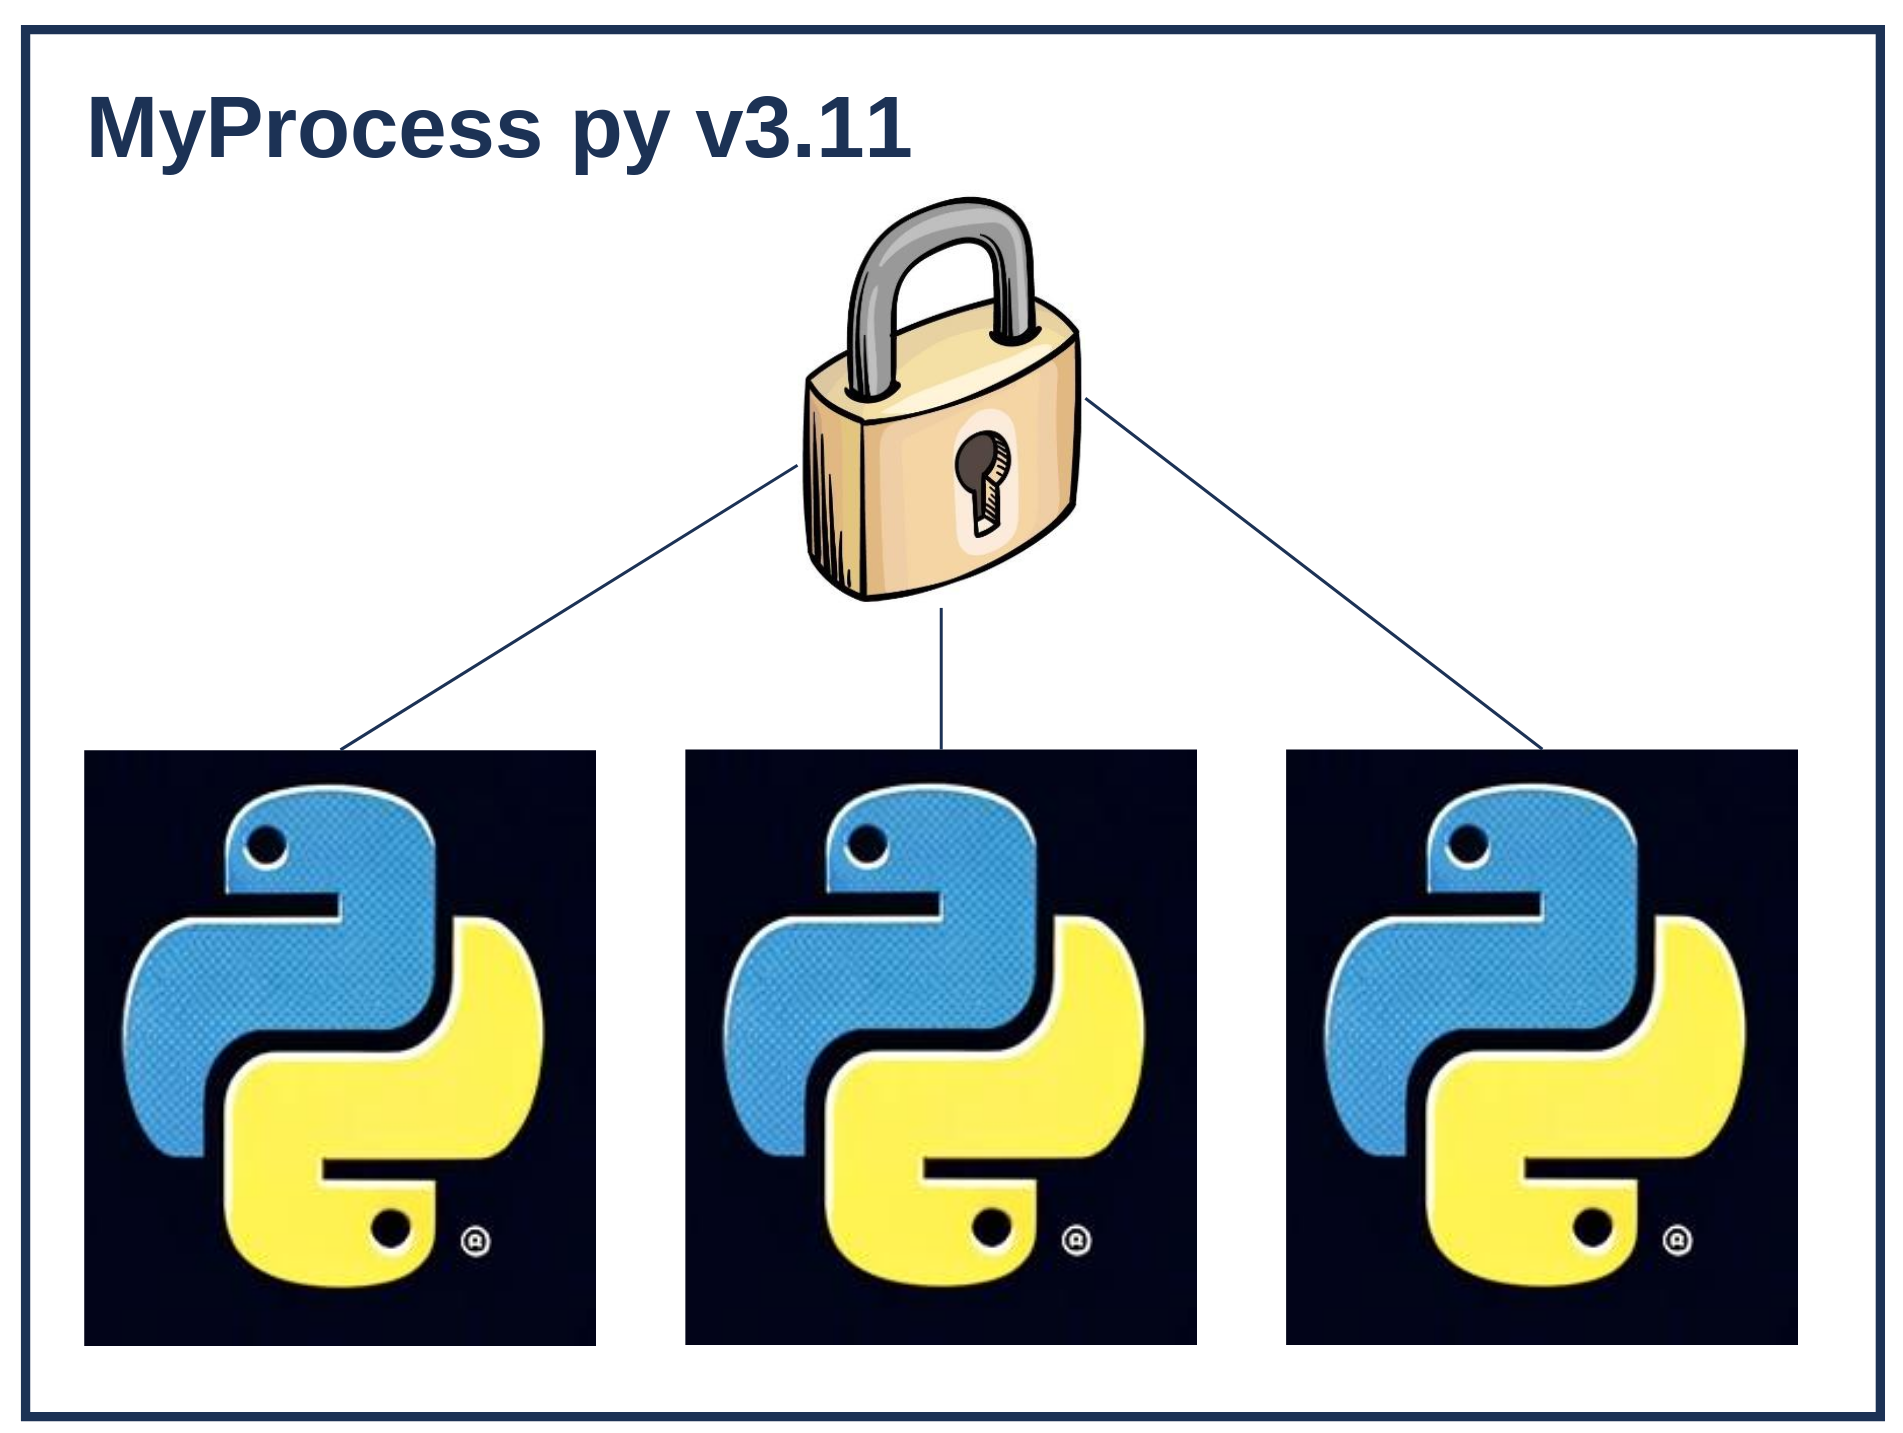
</div>

# ~Global~ Local Interpreter Lock


<div align="center">
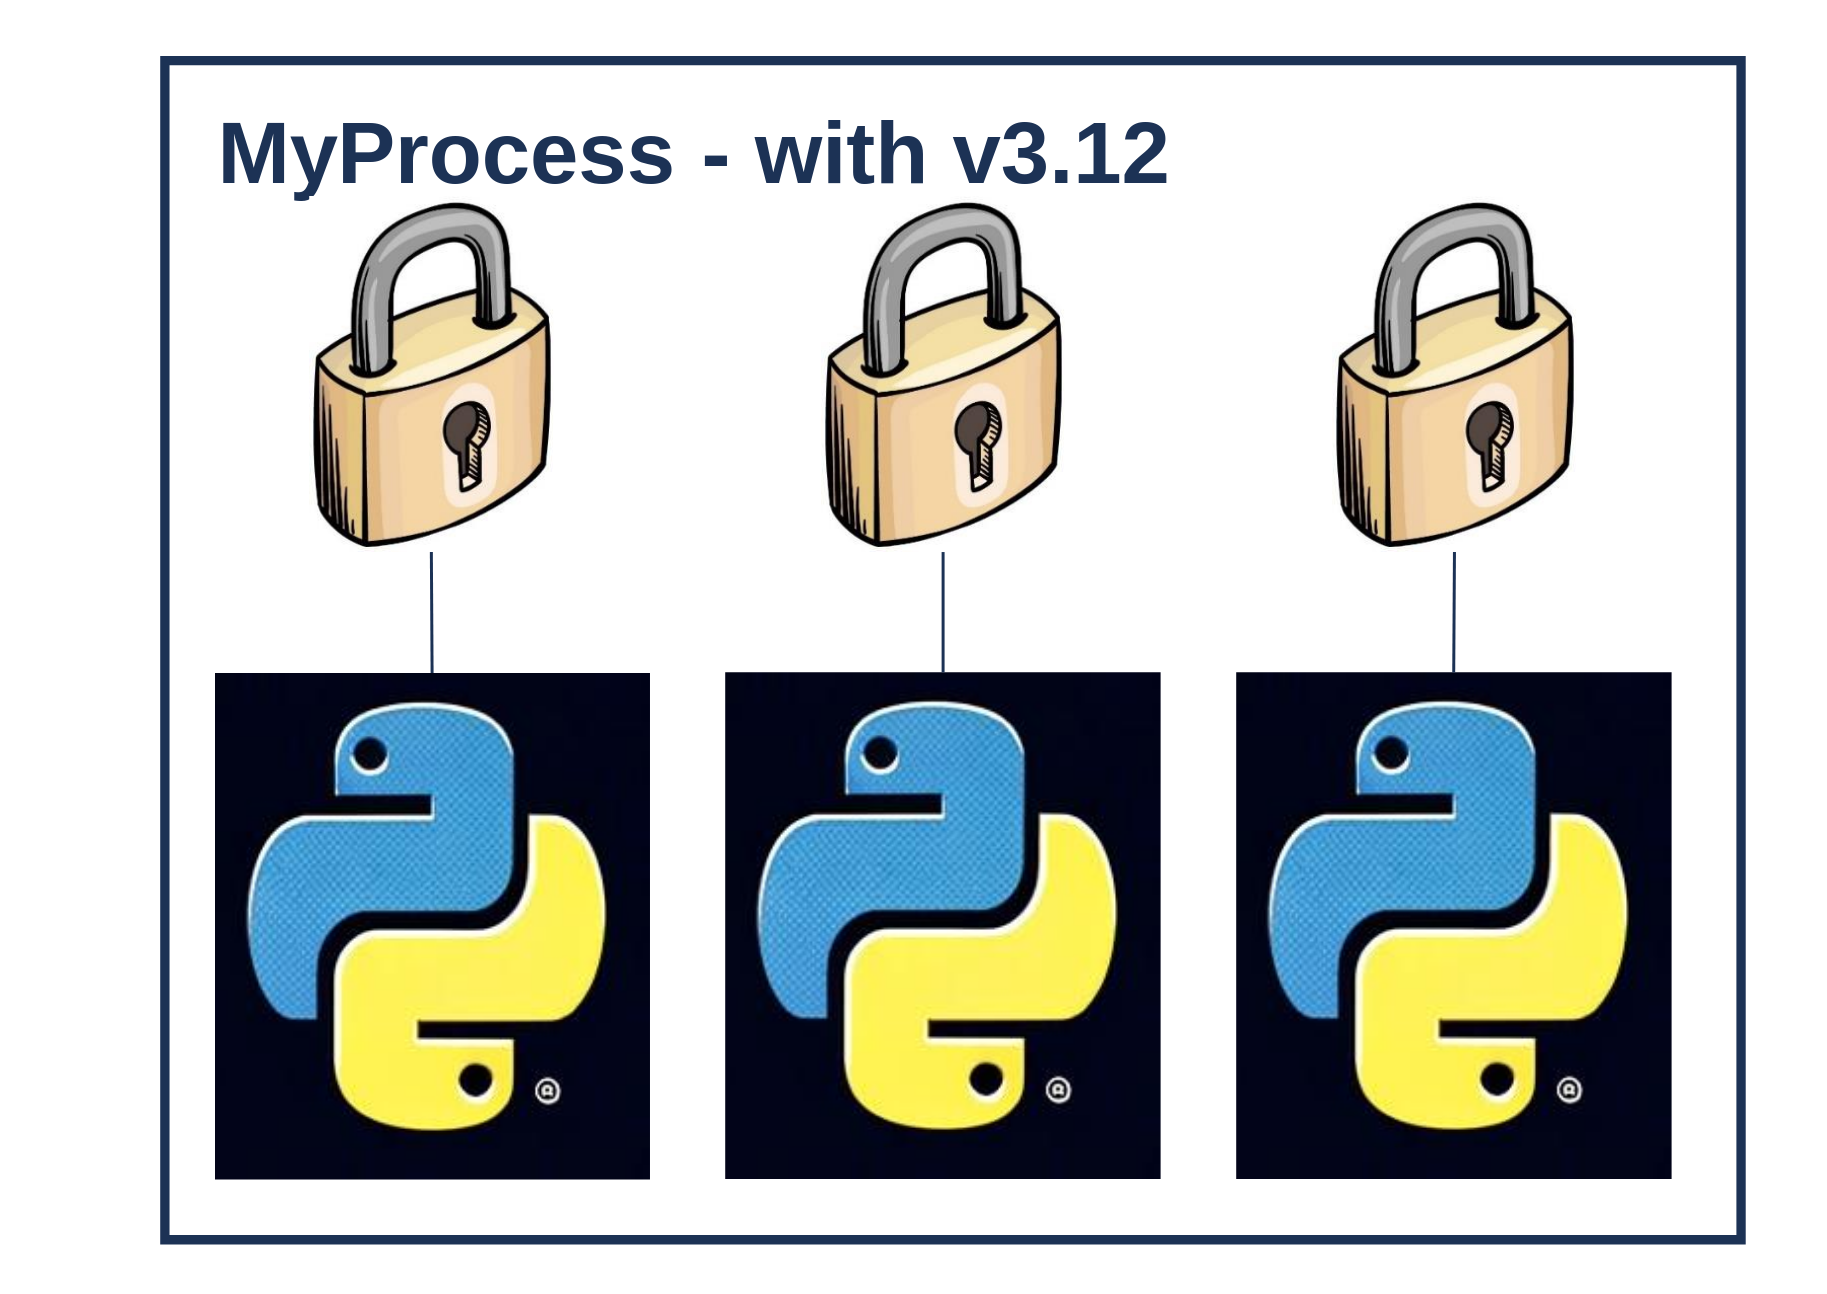
</div>

- **Paralelismo real** entre subinterpreters
- **Aislamiento** de estado garantizado
- **Compatibilidad** con código existente

## La estructura real

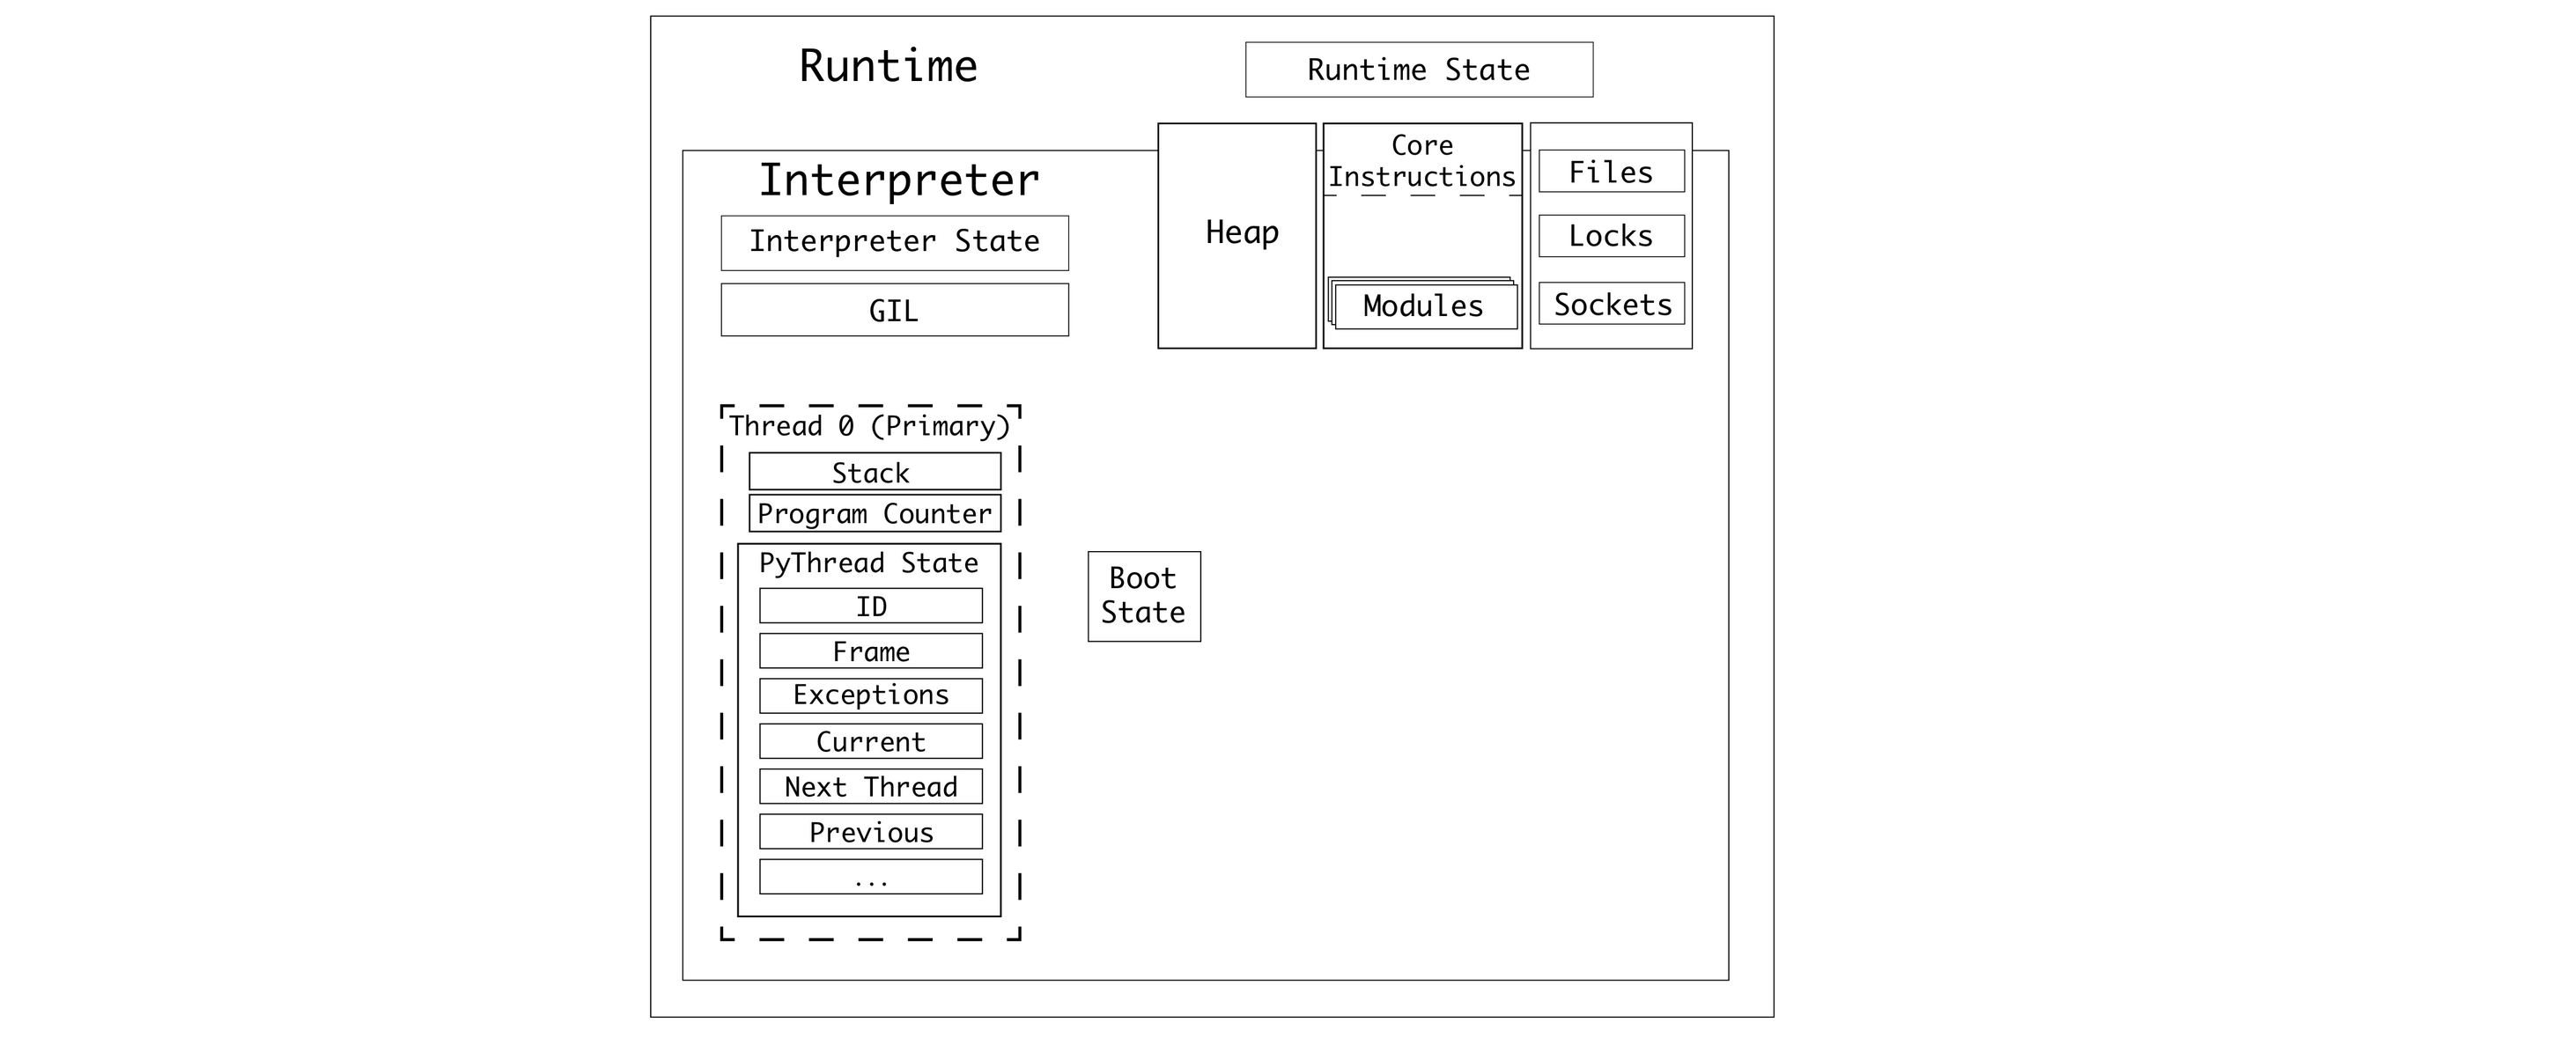


To learn more about this, you should read the “Parallelism and Concurrency” chapter of the book [CPython Internals](https://tonybaloney.github.io/#books).

## PEP 734/554: API de Python

### Objetivos
- Hacer subinterpreters **accesibles desde Python**
- Proporcionar **primitivas de comunicación**
- Base para **APIs de alto nivel** futuras

### Componentes Clave
- `interpreters` module
- `Queue` objects para comunicación
- `memoryview` para datos compartidos
- Sistema de tipos "shareables"

## Arquitectura Interna

### Estructura del Proceso

```
Main Process
├── Main Interpreter (GIL 1)
│   ├── Thread 1
│   ├── Thread 2
│   └── Global State 1
├── Subinterpreter 1 (GIL 2)  
│   ├── Thread 3
│   ├── Thread 4
│   └── Global State 2
└── Subinterpreter 2 (GIL 3)
    ├── Thread 5
    └── Global State 3
```

## Comparación: Threading vs Multiprocessing vs Subinterpreters

| Aspecto | Threading | Multiprocessing | Subinterpreters |
|---------|-----------|-----------------|-----------------|
| **Paralelismo CPU** | ❌ (GIL) | ✅ | ✅ |
| **Overhead startup** | Muy Bajo | Muy Alto | Medio |
| **Comunicación** | Instantánea | Serialización | Queue nativo |
| **Memoria** | Compartida | Separada | Selectiva |
| **Aislamiento** | No | Completo | Controlado |
| **Debugging** | Complejo | Muy Complejo | Medio |

## Los subinterpreters bloquean al ser inicializados

So most of the time you want to start one inside a thread.

In [2]:
from threading import Thread

interpreter = interpreters.create()


def target():
    print("hello world")

t = Thread(target=interpreters.run_func, args=(interpreter, target))
t.start()


## Running interpreters

Once an interpreter is running (remembering what I said that it is preferable to leave them running) you can share data using a channel. The channels module is also part of PEP554 and available using a secret-import:

**No lo logre hacer andar**

```python
import _interpreters as interpreters
import _interpchannels as channels

interp_id = interpreters.create()
channel_id = channels.create(1)

interpreters.run_string(
    interp_id, 
"""
import _interpchannels as channels
channels.send(channel_id, 'hello!')
""",
    shared={
        "channel_id": channel_id
    }
)
print(channels.recv(channel_id))
```

## Benchmarks: Tiempo de Startup

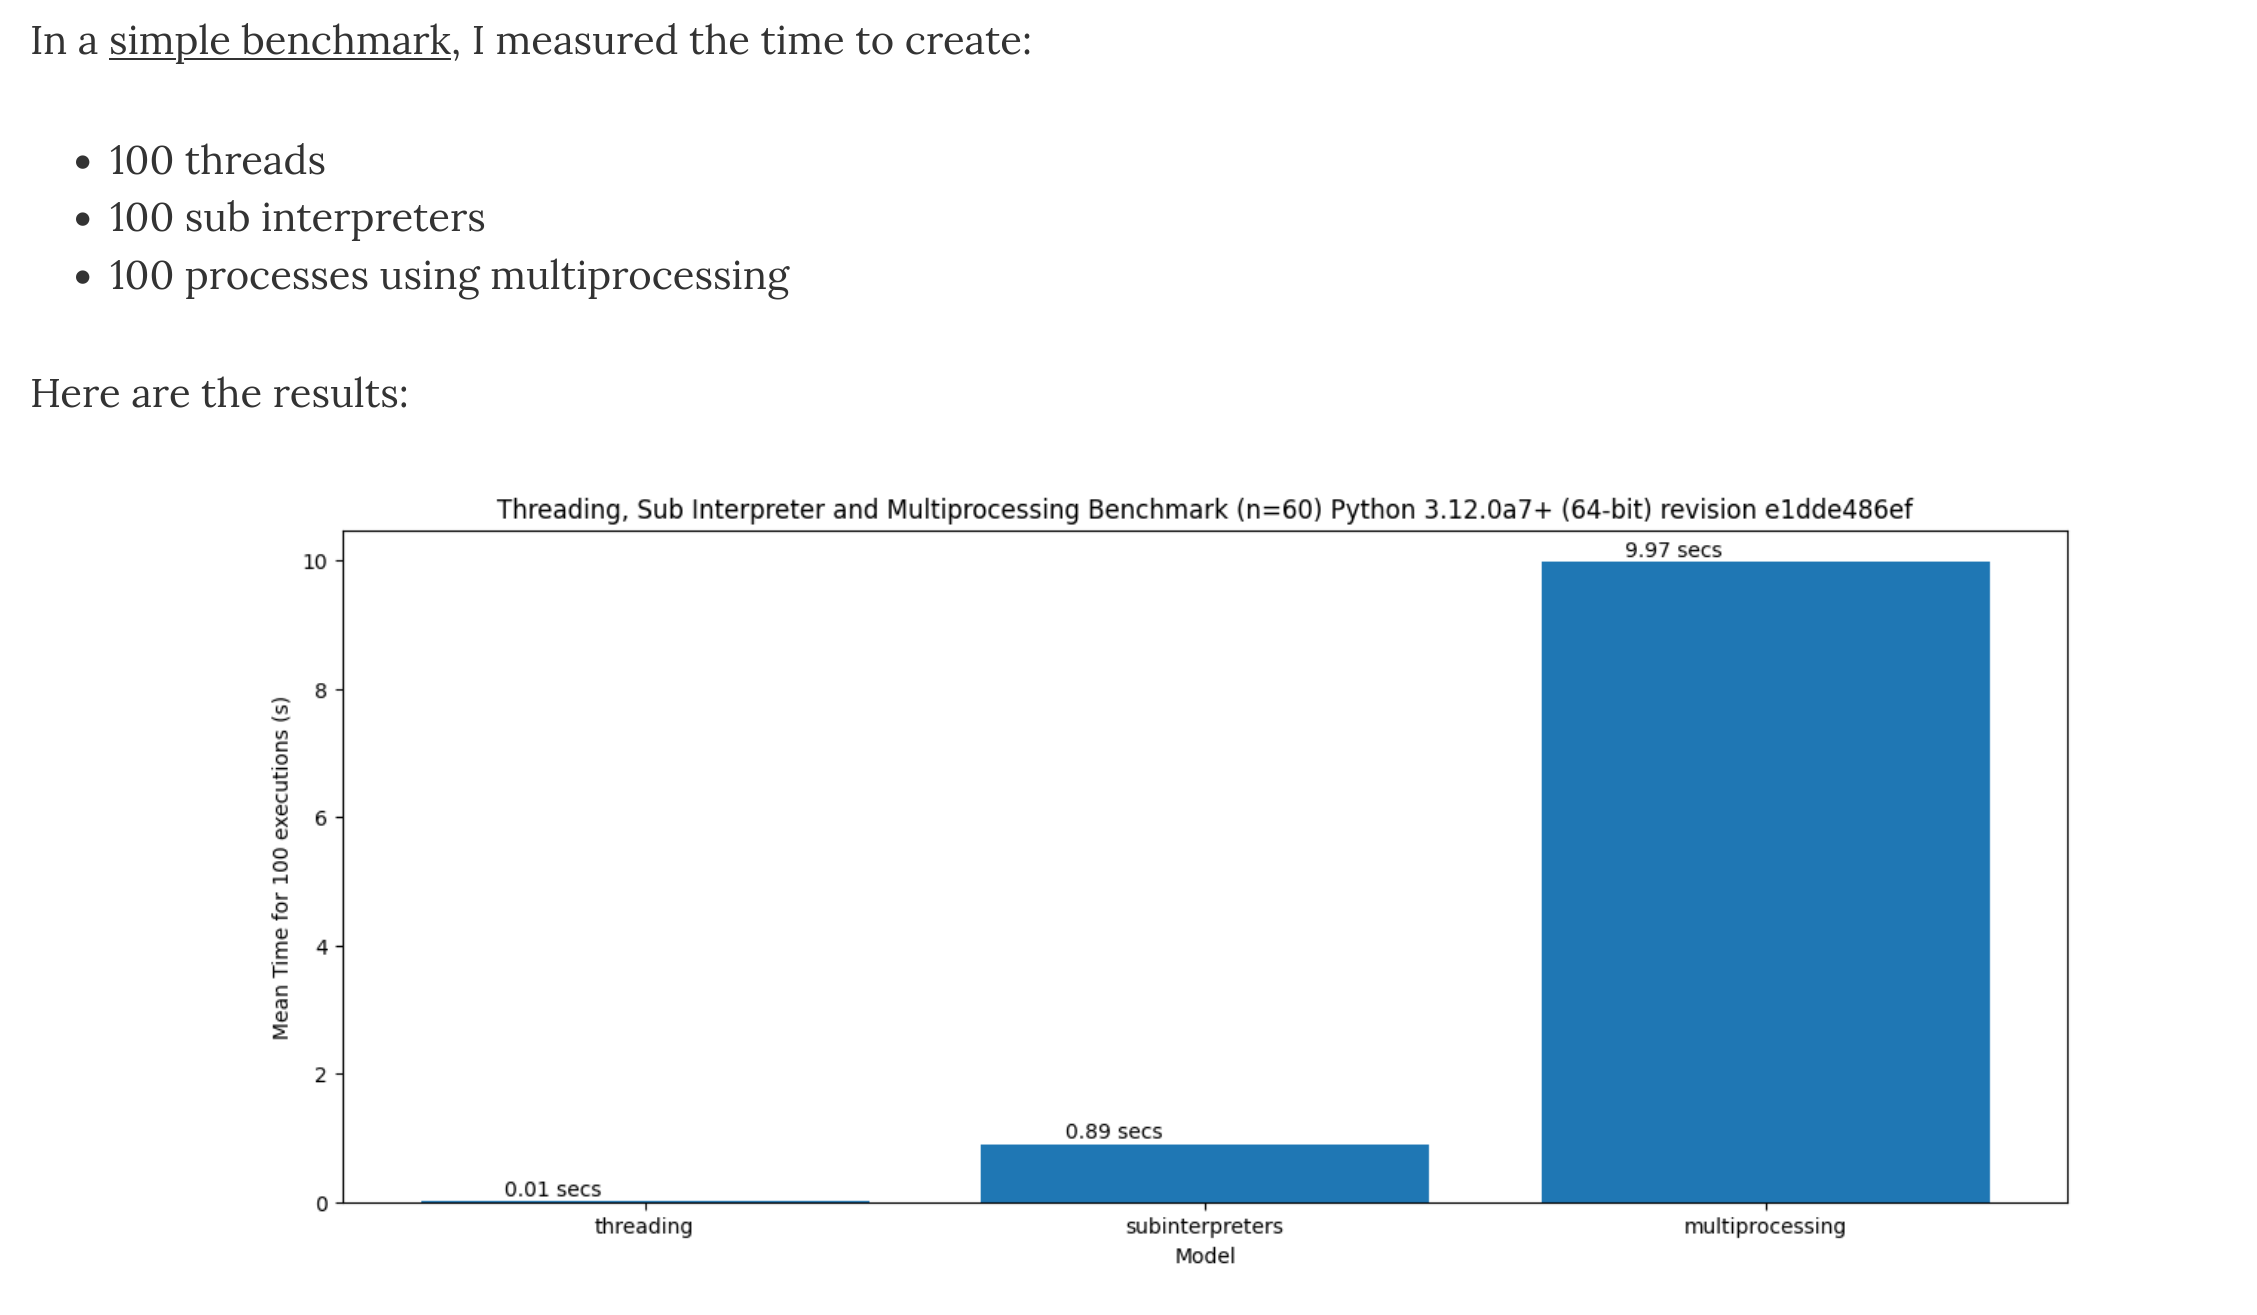

Fork vs Spawn

## Benchmarks: Pi!

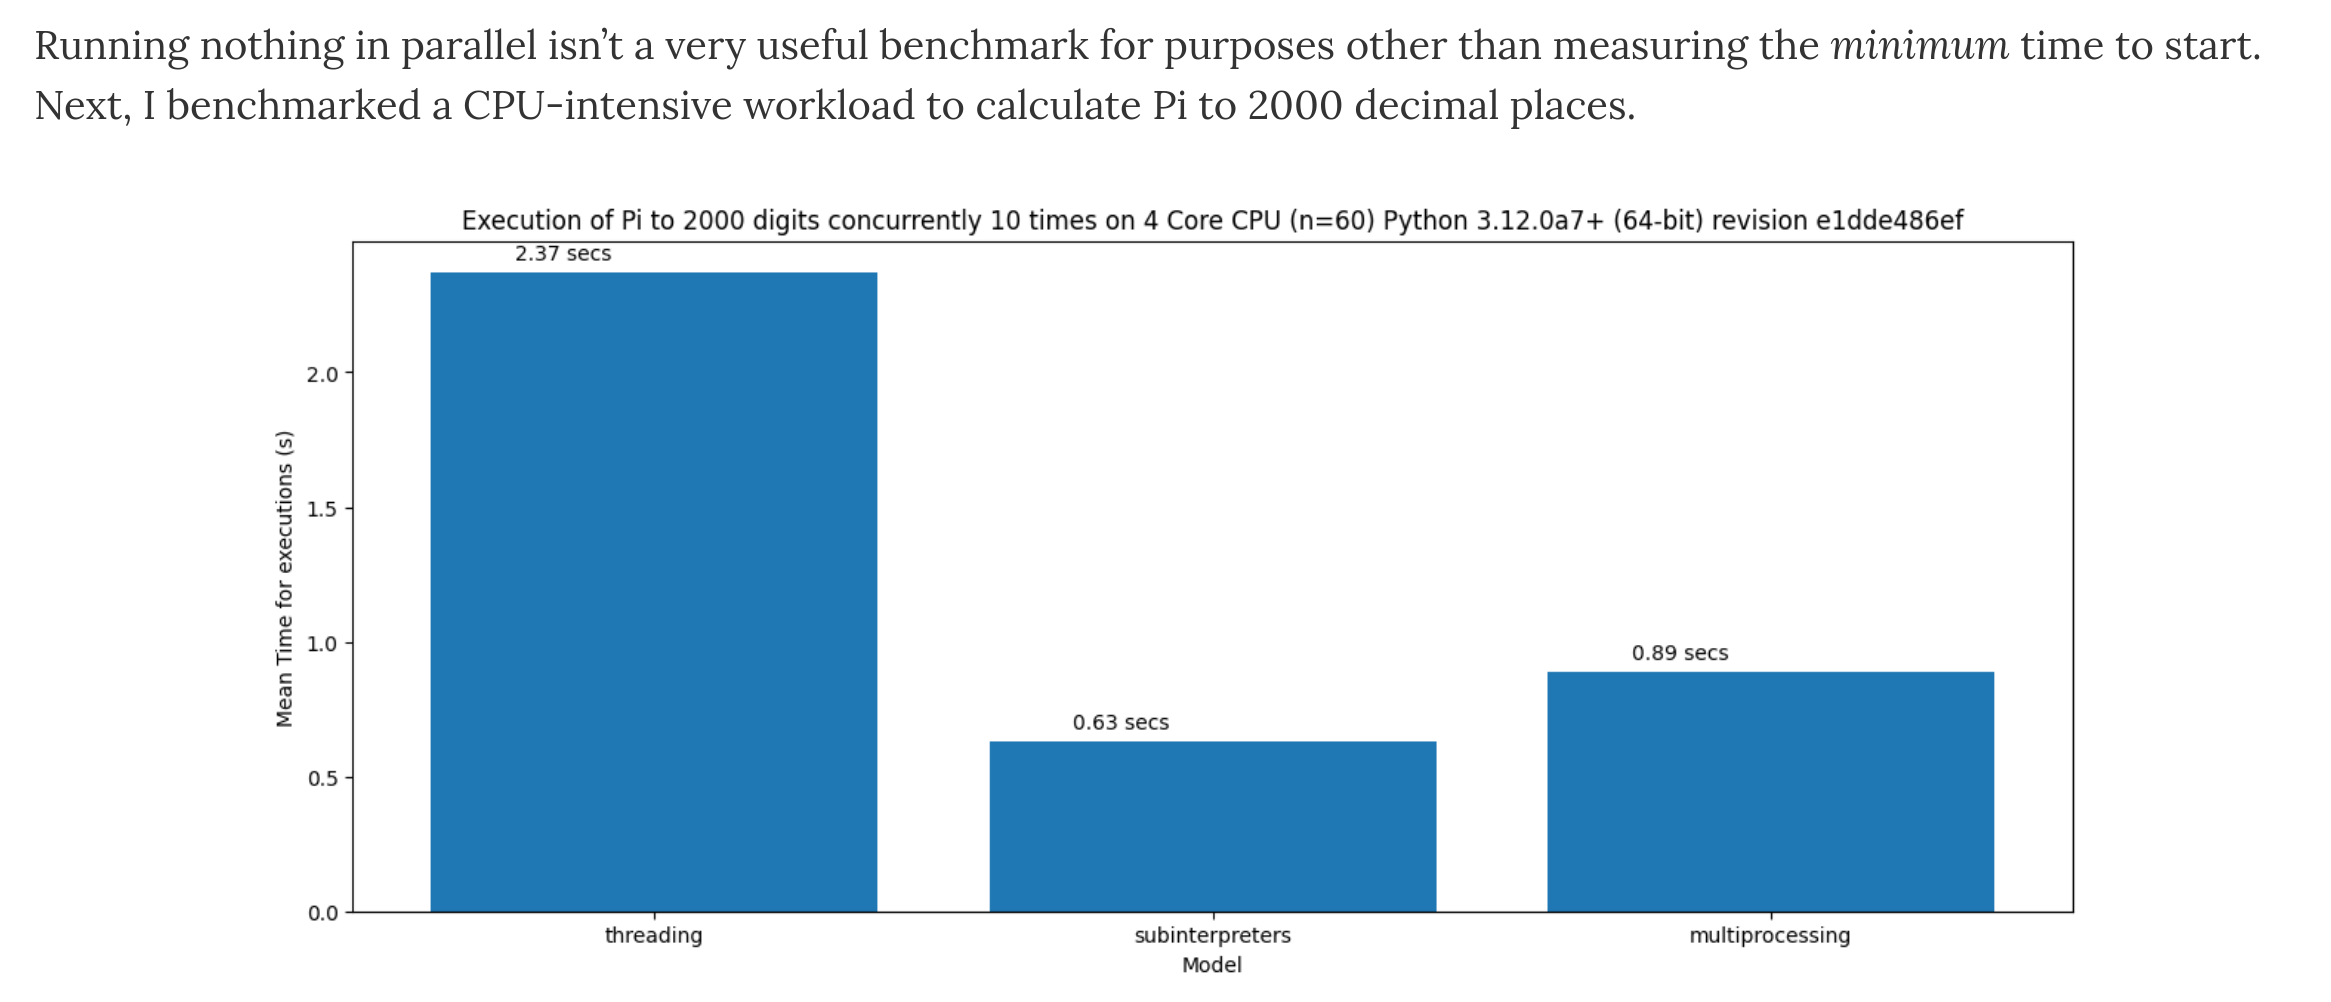

## Comparación: Free-Threading vs Subinterpreters

| Métrica | Free-Threading | Subinterpreters |
|---------|----------------|-----------------|
| **Estabilidad** | ⚠️ Muy experimental | ✅ Funcional |
| **Performance** | 🔄 Variable | ✅ Predecible |
| **Ecosystem** | ❌ Mínimo | ⚠️ Limitado |
| **Complejidad uso** | Alta | Media |
| **Overhead** | Bajo | Medio |
| **Debugging** | Muy difícil | Manejable |
| **Futuro** | Incierto | Prometedor |

### Recomendación Actual
**Subinterpreters** son más maduros y prácticos para uso real

## Limitaciones: Ecosystem Support

### Librerías Problemáticas

```python
# ❌ NumPy - Causa segfaults
import numpy as np  # Crash en subinterpreter

# ❌ Cython modules - Bloquean explícitamente  
import pandas as pd  # ImportError

# ❌ PyO3 (Rust) - No compatible
import pydantic  # No funciona

# ⚠️ ctypes - Soporte limitado
import ctypes  # Funciona parcialmente
```

### Módulos que SÍ Funcionan

```python
# ✅ Standard library
import math, json, re, time, os

# ✅ Pure Python packages
import requests, click

# ✅ Algunos C extensions actualizados
import array  # Funciona desde 3.13rc2
```

### Mejores Prácticas

In [ ]:
# Usar logging estructurado
worker_code = f"""
import logging
logger = logging.getLogger('worker_{worker_id}')
logger.info("Processing task", extra={{"worker_id": {worker_id}}})
"""

# Manejo explícito de errores
try:
    success, result = result_queue.get(timeout=30)
    if not success:
        logger.error(f"Worker error: {result}")
except queue.Empty:
    logger.error("Worker timeout")


## Casos de Uso Ideales

### ✅ Excelentes para Subinterpreters

# 1. CPU-bound con poca comunicación
```python
def process_images(image_list):
    return [heavy_image_processing(img) for img in image_list]
```

# 2. Simulaciones independientes
```python
def monte_carlo_simulation(params):
    return run_simulation(params, iterations=1_000_000)
```

# 3. Procesamiento de arrays grandes
```python
def process_array_chunk(array_view, start, end):
    for i in range(start, end):
        array_view[i] = complex_computation(array_view[i])
```


### ⚠️ Casos Problemáticos

- Mucha comunicación inter-worker
- Dependencias NumPy/SciPy
- Tareas muy cortas (<10ms)
- Debugging intensivo necesario


## Roadmap: Python 3.13+

### Mejoras Confirmadas
- **API más pythónica** para creación
- **Mejor error handling** 
- **Performance improvements**
- **Más módulos stdlib compatibles**

### En Desarrollo

```python
# Posible API futura más friendly
import concurrent.subinterpreters as subint

async def future_api():
    async with subint.Pool(workers=4) as pool:
        results = await pool.map(my_function, data)
    return results
```

## Roadmap: Largo Plazo

### Características Planeadas
- **Native shared objects** (no solo memoryview)
- **Better ecosystem integration**
- **Integration con asyncio**
- **Performance optimizations**

### Ejemplo Visión Futura

In [ ]:
# Hipotético: shared objects nativos
shared_dict = interpreters.SharedDict()
shared_list = interpreters.SharedList()

# Hipotético: asyncio integration  
async def async_subinterpreter():
    interp = await interpreters.create_async()
    result = await interp.exec_async(code)
    return result


## Comparación Final: Cuándo Usar Qué

### Decision Tree

```python
# ¿Es I/O bound?
if io_bound:
    use_asyncio()  # o threading

# ¿Es CPU bound?
elif cpu_bound:
    if needs_ecosystem_libraries:
        use_multiprocessing()
    elif high_communication_frequency:
        use_multiprocessing()  
    elif startup_performance_critical:
        use_subinterpreters()
    elif shared_array_processing:
        use_subinterpreters()
    else:
        use_multiprocessing()  # Más maduro

# ¿Es mixed workload?
else:
    consider_hybrid_approach()
```

## Mejores Prácticas

### Design Patterns

```python
# 1. Pool Pattern - Reutilizar subinterpreters
pool = SubinterpreterPool(workers=cpu_count())

# 2. Pipeline Pattern - Stages independientes  
stage1_pool = SubinterpreterPool("module1", "process", 4)
stage2_pool = SubinterpreterPool("module2", "transform", 4)

# 3. Shared Memory Pattern - Arrays grandes
shared_view = memoryview(large_array)
# Distribuir chunks a workers

# 4. Error Isolation - Fault tolerance
try:
    result = worker_pool.process(data)
except SubinterpreterError:
    # Reiniciar pool, logging, etc.
    handle_worker_failure()
```

## Conclusiones

### Estado Actual (2024)
- ✅ **Funcionalmente completo** para casos específicos
- ⚠️ **Ecosystem support limitado** pero mejorando
- ✅ **Performance predecible** y escalable
- ⚠️ **API en evolución** hacia más usabilidad

### Adopción Recomendada
- **Early adopters**: Experimentar en proyectos no críticos
- **Production**: Evaluar trade-offs vs multiprocessing
- **Largo plazo**: Prepararse para APIs mejoradas

### El Futuro del Paralelismo en Python
**Subinterpreters + Free-threading = Toolkit completo**
- Subinterpreters: Paralelismo robusto, casos específicos
- Free-threading: Paralelismo general, experimental
- Juntos: Cobertura completa de casos de uso

## Recursos y Referencias

### Documentación Oficial
- **PEP 684**: Per-Interpreter GIL
- **PEP 734**: Multiple Interpreters in Stdlib  
- **PEP 554**: Multiple Interpreters (legacy)

### Proyectos y Ejemplos
- **extrainterpreters**: Higher-level APIs
- **interpreters-backport**: Python 3.13 features en 3.12

### Benchmarks y Casos Reales
- [Anthony Shaw's blog posts](https://tonybaloney.github.io/posts/sub-interpreter-web-workers.html)
- Jamie Chang's AOC implementation
- [EuroPython 2024 talks](https://ep2024.europython.eu/session/python-in-parallel-sub-interpreters-vs-nogil-vs-multiprocessing/)
